# Part 2c — CVaR, and a number that was not what it looked like

### Same model as Part 2b. Different question.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/advopt-lithiumsc/blob/main/notebooks/02c_cvar.ipynb)

Part 2b asked *how do I solve this*. This one asks *what am I solving for*.
Minimising the expectation is a choice, and it is the choice that says a one-in-
twenty disaster and a one-in-two inconvenience are worth the same per unit of
cost. Sometimes that is right. Often nobody has checked.

Four objectives over the same scenario set:

| | minimises | in one line |
|---|---|---|
| **neutral** | $\mathbb{E}[\text{cost}]$ | the Part 2b answer |
| **CVaR** | mean of the worst $\alpha$ fraction | ignore the good outcomes entirely |
| **robust** | the maximum | one scenario decides everything |
| **hybrid** | $\lambda \mathbb{E} + (1-\lambda)\,\text{CVaR}$ | a dial between the first two |

### The thing this notebook is really about

CVaR is the easy part — it linearises, and section 5 does it in eight lines. The
hard part is **reading the answer**, and the original version of this notebook
got it wrong in a way worth reproducing deliberately.

It reported the robust plan's average cost as 2245.5, some 40% above the
risk-neutral plan's, and concluded that minimax is ruinously expensive on
average. In fact the robust plan is *the same plan* as the CVaR one, and its
true average cost is 1642.2. Section 6 shows where 2245.5 came from and why it
was never a property of the plan.

**Three of the four objectives choose one identical capacity plan and report
three different average costs for it.** Only one of those can be right, and in
fact none of them is: section 6 measures the spread and section 7 computes the
number that is actually a property of the plan. That is the lesson; CVaR is the
vehicle.

## 0. Setup

One cell, and it is the only place the `lithium` package appears before the final check. On Colab it
clones the repo and installs it; locally it assumes you have already run `pip install -e .` and just
moves up out of `notebooks/` so the relative data paths work.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sear-labs/advopt-lithiumsc.git"
# Forked or renamed? Change BOTH halves of that path. Only the owner ever
# looked like a placeholder, and the repo name beside it broke 64 URLs once.
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if "google.colab" in sys.modules:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
print(f"working directory : {Path.cwd().name}")
print(f"gurobipy          : {gp.gurobi.version()}")
print(f"pandas            : {pd.__version__}")

working directory : Advanced Opt Modeling Examples
gurobipy          : (13, 0, 2)
pandas            : 2.3.3


## 2. The instance

**This is a third instance, and confusing it with the other two will waste an
hour.** Part 1 and Part 2 use a six-site, twenty-year network with vintages,
lead times and learning. Part 4 uses a two-region chain owned by competing
firms. This one is single-period: three stages, two regions, six capacity
nodes, twelve arcs, and no time at all.

It is smaller on purpose. Part 2b needs the **duals** of the capacity rows, and
for those to exist the second stage has to be a linear program. In Part 1's
model capacity is entangled with binaries, vintages and lead times, and there is
no clean dual to build a cut from.

| file | keyed by | rows |
|---|---|---|
| `twostage_stages.csv` | `stage` | 3 |
| `twostage_regions.csv` | `region` | 2 |

`region_cost` is read by both notebooks and used only by Part 2c; Part 2b has no
regional cost asymmetry. They are different models, not one model with a flag.

Read the two tables and look at them as frames before turning them into anything
the model indexes.

In [2]:
DATA = Path("data/raw")

if not (DATA / "twostage_stages.csv").exists():
    print("!" * 78)
    print("! data/raw/ was not found, so this notebook is FALLING BACK to generated")
    print("! numbers. Everything below will run and every figure will render, but the")
    print("! results are NOT the shipped instance and are NOT an acceptable submission.")
    print("! Fix: clone the repo (see section 0) or run this notebook from the repo root.")
    print("!" * 78)
    DATA = Path("_generated_fallback")
    DATA.mkdir(exist_ok=True)
    (DATA / "twostage_stages.csv").write_text(
        "stage,fix,unit,opc,eta\nMINE,240.0,2.2,0.8,0.95\n"
        "PROC,200.0,2.9,1.3,0.90\nMFG,160.0,3.3,1.6,0.93\n")
    (DATA / "twostage_regions.csv").write_text(
        "region,demand_base,region_cost\nR1,34.0,0.72\nR2,22.0,1.00\n")

stages_df = pd.read_csv(DATA / "twostage_stages.csv")
regions_df = pd.read_csv(DATA / "twostage_regions.csv")
print(f"twostage_stages.csv : {len(stages_df)} rows x {len(stages_df.columns)} columns")
print(f"twostage_regions.csv: {len(regions_df)} rows x {len(regions_df.columns)} columns")
stages_df

twostage_stages.csv : 3 rows x 5 columns
twostage_regions.csv: 2 rows x 3 columns


,stage,fix,unit,opc,eta
0,MINE,240.0,2.2,0.8,0.95
1,PROC,200.0,2.9,1.3,0.90
2,MFG,160.0,3.3,1.6,0.93


A frame shows rows and columns. The model does not index by row number — it
indexes by `stage` and by `region`. Print the dictionary form so the **key** is
explicit rather than implied by the layout.

In [3]:
STAGES = tuple(stages_df["stage"])
REGIONS = tuple(regions_df["region"])

FIX = dict(zip(stages_df["stage"], stages_df["fix"].astype(float)))
UNIT = dict(zip(stages_df["stage"], stages_df["unit"].astype(float)))
OPC = dict(zip(stages_df["stage"], stages_df["opc"].astype(float)))
ETA = dict(zip(stages_df["stage"], stages_df["eta"].astype(float)))
DEMAND_BASE = dict(zip(regions_df["region"], regions_df["demand_base"].astype(float)))
REGION_COST = dict(zip(regions_df["region"], regions_df["region_cost"].astype(float)))

print(f"STAGES  {STAGES}")
print(f"REGIONS {REGIONS}")
for name, d in (("FIX", FIX), ("UNIT", UNIT), ("OPC", OPC), ("ETA", ETA)):
    print(f"{name:12s} {d}")
print(f"{'DEMAND_BASE':12s} {DEMAND_BASE}")
print(f"{'REGION_COST':12s} {REGION_COST}   (Part 2c only)")

# Try it: give R2 the cheaper operating costs instead and watch section 11
# stay green, because the package is handed this table rather than re-reading it.
# REGION_COST["R1"], REGION_COST["R2"] = 1.00, 0.72

STAGES  ('MINE', 'PROC', 'MFG')
REGIONS ('R1', 'R2')
FIX          {'MINE': 240.0, 'PROC': 200.0, 'MFG': 160.0}
UNIT         {'MINE': 2.2, 'PROC': 2.9, 'MFG': 3.3}
OPC          {'MINE': 0.8, 'PROC': 1.3, 'MFG': 1.6}
ETA          {'MINE': 0.95, 'PROC': 0.9, 'MFG': 0.93}
DEMAND_BASE  {'R1': 34.0, 'R2': 22.0}
REGION_COST  {'R1': 0.72, 'R2': 1.0}   (Part 2c only)


## 3. The knobs, and the sets derived from them

Everything in this section is either a **knob** — a scalar carrying a concept,
written out here where the sentence explaining it is — or **arithmetic** on the
tables above. Nothing here is data.

The four knobs:

- `CMIN`, `CMAX` — a node that opens at all must be at least `CMIN` and at most
  `CMAX`. Together with the binary `y` this is what makes stage 1 a *discrete*
  decision rather than a continuous one, and therefore what makes the master
  problem in Part 2b a MILP.
- `PEN` — the penalty per unit of unmet demand. It has to exceed the cost of
  serving that demand the expensive way, or the model will simply decline to
  serve it.
- `TAU_OWN`, `TAU_CROSS` — transport within a region and across regions.

In [4]:
CMIN, CMAX = 5.0, 70.0        # a node that opens is between these
PEN = 30.0                    # per unit of unmet demand
TAU_OWN, TAU_CROSS = 0.3, 1.5   # transport within / across regions

NODES = [(s, r) for s in STAGES for r in REGIONS]
ARCS = [(s, a, b) for s in STAGES for a in REGIONS for b in REGIONS]
TAU = {(a, b): (TAU_OWN if a == b else TAU_CROSS)
       for a in REGIONS for b in REGIONS}

print(f"{len(NODES)} capacity nodes, {len(ARCS)} arcs")
print(f"nodes: {NODES}")
print(f"TAU  : {TAU}")
print(f"\ncrossing a region costs {TAU_CROSS / TAU_OWN:.0f}x what staying home does,")
print(f"and PEN = {PEN} is {PEN / max(OPC.values()):.0f}x the dearest stage's opex,")
print("so unmet demand is a last resort rather than a cheap way out.")

6 capacity nodes, 12 arcs
nodes: [('MINE', 'R1'), ('MINE', 'R2'), ('PROC', 'R1'), ('PROC', 'R2'), ('MFG', 'R1'), ('MFG', 'R2')]
TAU  : {('R1', 'R1'): 0.3, ('R1', 'R2'): 1.5, ('R2', 'R1'): 1.5, ('R2', 'R2'): 0.3}

crossing a region costs 5x what staying home does,
and PEN = 30.0 is 19x the dearest stage's opex,
so unmet demand is a last resort rather than a cheap way out.


### 3.1 What a plan can physically deliver

Yields compound down the chain, so a MINE node of capacity $c$ can support at
most $\eta_{\text{MINE}} c$ of processing and $\eta_{\text{MINE}}
\eta_{\text{PROC}} c$ of manufacturing. That product is worth computing now,
because it turns up as the answer later: the optimal plans in both notebooks sit
exactly on this chain rather than anywhere in between.

In [5]:
chain = 1.0
for s in STAGES:
    chain *= ETA[s]
    print(f"a unit of MINE capacity supports {chain:.4f} through {s}")

MAX_DELIVERABLE = CMAX * ETA[STAGES[0]] * ETA[STAGES[1]]
print(f"\none full-size chain ({CMAX:.0f} at each stage, sized down the yields):")
print(f"  {CMAX:.2f} -> {CMAX * ETA[STAGES[0]]:.2f} -> {MAX_DELIVERABLE:.4f}")
print(f"total peak demand across regions can reach "
      f"{sum(DEMAND_BASE.values()) * 1.55:.1f}, so one chain is not obviously enough")

a unit of MINE capacity supports 0.9500 through MINE
a unit of MINE capacity supports 0.8550 through PROC
a unit of MINE capacity supports 0.7952 through MFG

one full-size chain (70 at each stage, sized down the yields):
  70.00 -> 66.50 -> 59.8500
total peak demand across regions can reach 86.8, so one chain is not obviously enough


## 4. Scenarios: demand, and a shock that has to fall unevenly

Part 2b varied demand alone. That is not enough to make risk aversion change the
*plan* here, and the reason is worth stating before the code.

**A shock that scales every region equally cannot change which plan is best.** It
multiplies every plan's cost by the same factor, so the ranking is untouched and
risk aversion moves the reported numbers without moving the decision. For the
plan to change, the shock has to fall unevenly, so that *where* you put capacity
is what determines your exposure.

So: R1 is the cheap region — `REGION_COST` says 0.72 against R2's 1.00 — and it
is also the one occasionally disrupted. R2 is dearer and steady. That is the
trade a risk-averse planner is being asked to make, and it is a real one rather
than an arithmetic artefact.

In [6]:
import random

SEED, NK = 7, 40
LO, SPAN = 0.6, 0.9            # demand multiplier range
HIT_PROB, HIT_SIZE = 0.15, 2.6   # R1 disruption: how often, how bad
STEADY_JITTER = 0.15           # R2's mild variation
DISRUPTED = "R1"

rng = random.Random(SEED)
SCEN = []
for k in range(NK):
    hit = rng.random() < HIT_PROB          # the coin, drawn first
    d = {r: DEMAND_BASE[r] * (LO + SPAN * rng.random()) for r in REGIONS}
    mult = {}
    for r in REGIONS:
        if r == DISRUPTED:
            mult[r] = 1.0 + (HIT_SIZE * rng.random() if hit else 0.0)
        else:
            mult[r] = 1.0 + STEADY_JITTER * rng.random()
    SCEN.append((f"k{k}", 1.0 / NK, d, mult))

nhit = sum(1 for s in SCEN if s[3][DISRUPTED] > 1.0)
assert abs(sum(s[1] for s in SCEN) - 1.0) < 1e-12, "probabilities must sum to 1"
print(f"seed {SEED}, {NK} equally likely scenarios")
print(f"{DISRUPTED} disrupted in {nhit} of them ({100 * nhit / NK:.0f}%)")
for r in REGIONS:
    print(f"  {r}: cost multiplier {min(s[3][r] for s in SCEN):.2f}"
          f"-{max(s[3][r] for s in SCEN):.2f}   "
          f"base operating cost x{REGION_COST[r]:.2f}")

seed 7, 40 equally likely scenarios
R1 disrupted in 14 of them (35%)
  R1: cost multiplier 1.00-3.27   base operating cost x0.72
  R2: cost multiplier 1.01-1.15   base operating cost x1.00


Note the **draw order**, which is part of the definition: the disruption coin,
then demand for each region, then the multipliers — and the disrupted region
consumes a random draw only when the coin came up heads. Move any of those and
the same seed gives a different tree.

The realised disruption rate is 35%, not the 15% the parameter names. With forty
draws that is ordinary sampling variation, and it is worth printing rather than
assuming: a reader who sees `HIT_PROB = 0.15` and expects six disrupted
scenarios would otherwise misread every table below.

## 5. One model, four objectives

The first stage and the recourse blocks are Part 2b's, with one addition: the
operating cost is now multiplied by the region's base cost **and** by that
scenario's shock. Everything else is identical.

### CVaR, and why it is linear

$\text{CVaR}_\alpha$ is the mean of the worst $\alpha$ fraction of outcomes.
Written directly that needs a sort, which is not something a solver can
differentiate. The Rockafellar–Uryasev trick replaces it with

$$\min_{\eta}\;\; \eta + \frac{1}{\alpha}\sum_k p_k \,[\,C_k - \eta\,]^+$$

and the positive part becomes a variable $z_k \ge C_k - \eta$, $z_k \ge 0$.
**Those two lines are the whole technique.** At the optimum $\eta$ is the
value-at-risk and $z_k$ the excess above it.

In [7]:
import gurobipy as gp
from gurobipy import GRB

ALPHA, LAM = 0.10, 0.01
MIPGAP = 1e-9


# THE FUNCTION IS THE LESSON: the point of this section is that the four
# objectives sit on ONE model. Writing the model out four times would let the
# copies drift, and then a difference between two rows of section 7's table
# could be a difference in the objective or a typo in a constraint, with no way
# to tell which.
def risk_model(mode, alpha=ALPHA, lam=LAM, tiebreak=0.0):
    m = gp.Model(mode)
    m.Params.OutputFlag = 0
    m.Params.MIPGap = MIPGAP
    y = m.addVars(NODES, vtype=GRB.BINARY, name="y")
    c = m.addVars(NODES, lb=0.0, ub=CMAX, name="c")
    m.addConstrs((c[n] <= CMAX * y[n] for n in NODES))
    m.addConstrs((c[n] >= CMIN * y[n] for n in NODES))
    first = gp.quicksum(FIX[s] * y[s, r] + UNIT[s] * c[s, r] for (s, r) in NODES)

    cost = {}
    for j, scen in enumerate(SCEN):
        x = m.addVars(NODES, lb=0.0)
        f = m.addVars(ARCS, lb=0.0)
        u = m.addVars(REGIONS, lb=0.0)
        m.addConstrs((x[n] <= c[n] for n in NODES))
        m.addConstrs((ETA[s] * x[s, r] == f.sum(s, r, "*") for (s, r) in NODES))
        for i, s in enumerate(STAGES):
            if i == 0:
                continue
            m.addConstrs((f.sum(STAGES[i - 1], "*", r) == x[s, r] for r in REGIONS))
        m.addConstrs((f.sum(STAGES[-1], "*", r) + u[r] >= scen[2][r]
                      for r in REGIONS))
        cost[j] = (gp.quicksum(scen[3][r] * REGION_COST[r] * OPC[s] * x[s, r]
                               for (s, r) in NODES)
                   + gp.quicksum(TAU[a, b] * f[s, a, b] for (s, a, b) in ARCS)
                   + gp.quicksum(PEN * u[r] for r in REGIONS))

    eta = m.addVar(lb=-GRB.INFINITY, name="eta")     # the VaR level
    z = m.addVars(range(NK), lb=0.0, name="z")       # excess above it
    m.addConstrs((z[j] >= first + cost[j] - eta for j in range(NK)), name="cvar")
    CVAR = eta + (1.0 / alpha) * gp.quicksum(SCEN[j][1] * z[j] for j in range(NK))
    EXP = first + gp.quicksum(SCEN[j][1] * cost[j] for j in range(NK))

    if mode == "neutral":
        m.setObjective(EXP, GRB.MINIMIZE)
    elif mode == "cvar":
        m.setObjective(CVAR + tiebreak * EXP, GRB.MINIMIZE)
    elif mode == "robust":
        w = m.addVar(lb=0.0, name="worst")
        m.addConstrs((w >= first + cost[j] for j in range(NK)), name="minimax")
        m.setObjective(w + tiebreak * EXP, GRB.MINIMIZE)
    elif mode == "hybrid":
        m.setObjective(lam * EXP + (1 - lam) * CVAR, GRB.MINIMIZE)
    else:
        raise ValueError(f"unknown mode {mode!r}")

    m.optimize()
    assert m.SolCount > 0, f"the {mode} model found no solution"
    reported = sorted(first.getValue() + cost[j].getValue() for j in range(NK))
    ncrit = max(1, int(round(alpha * NK)))
    return dict(mode=mode, obj=m.ObjVal, plan={n: c[n].X for n in NODES},
                reported_mean=sum(reported) / NK,
                reported_cvar=sum(reported[-ncrit:]) / ncrit,
                reported_worst=reported[-1])


print(f"alpha = {ALPHA}: CVaR averages the worst "
      f"{max(1, int(round(ALPHA * NK)))} of {NK} scenarios")
print(f"lambda = {LAM}: the hybrid weights the mean at {LAM:.2f} "
      f"and CVaR at {1 - LAM:.2f}")

alpha = 0.1: CVaR averages the worst 4 of 40 scenarios
lambda = 0.01: the hybrid weights the mean at 0.01 and CVaR at 0.99


## 6. Before reading any of it: the numbers that model reports are not comparable

`risk_model` returns `reported_mean`, `reported_cvar` and `reported_worst`,
computed from the solution vector it got back. It is the obvious thing to do and
it is wrong, and the way it is wrong is worth meeting before the results table
rather than after.

**Minimax constrains only the worst scenario.** The objective is $w \ge C_k$ for
all $k$, minimising $w$. Once $w$ is pinned by whichever scenario is worst, every
*other* scenario's recourse variables are unconstrained as far as the objective
cares — any feasible flow will do, including a wasteful one. The solver returns
one. Averaging those is averaging arbitrary numbers.

The same is true of pure CVaR for every scenario below the value-at-risk
threshold: they are outside the $\alpha$ tail, so their cost does not enter the
objective at all.

> **Predict before you run.** Four objectives, four plans. How many *distinct*
> capacity plans do you expect? And how many distinct reported means?

In [8]:
res = {mode: risk_model(mode) for mode in ("neutral", "cvar", "robust", "hybrid")}

plans = {m: tuple(round(r["plan"][n], 6) for n in NODES) for m, r in res.items()}
distinct = {v: [m for m in plans if plans[m] == v] for v in set(plans.values())}
print(f"{len(distinct)} distinct capacity plans among the four objectives:")
for v, modes in distinct.items():
    sited = [f"{s}/{r}" for (s, r) in NODES if v[NODES.index((s, r))] > 1e-6]
    print(f"  {', '.join(sorted(modes)):28s} -> {sited}")

print(f"\n{'mode':9s} {'reported mean':>14s}")
for m, r in res.items():
    print(f"{m:9s} {r['reported_mean']:14.1f}")

same = [m for m in res if plans[m] == plans["robust"]]
reported = {round(res[m]["reported_mean"], 4) for m in same}
print(f"\n{len(same)} objectives return the SAME plan: {sorted(same)}")
print(f"and {len(reported)} different reported means for it: {sorted(reported)}")
print(f"the dearest is {100 * (max(reported) / min(reported) - 1):.1f}% above "
      f"the cheapest, for one identical plan")
assert len(reported) > 1, (
    "the reported means happen to agree here, which would make this section's "
    "point invisible; check the scenario set before trusting the table above")

Restricted license - for non-production use only - expires 2027-11-29


2 distinct capacity plans among the four objectives:
  neutral                      -> ['MINE/R1', 'PROC/R1', 'MFG/R1']
  cvar, hybrid, robust         -> ['MINE/R2', 'PROC/R2', 'MFG/R2']

mode       reported mean
neutral           1602.1
cvar              2034.4
robust            2245.5
hybrid            1642.2

3 objectives return the SAME plan: ['cvar', 'hybrid', 'robust']
and 3 different reported means for it: [1642.1909, 2034.4364, 2245.4733]
the dearest is 36.7% above the cheapest, for one identical plan


**Three objectives, one identical plan, three different reported means.** CVaR,
minimax and the hybrid all choose to put the entire chain in R2 — the same six
numbers — and report its average cost as 2034.4, 2245.5 and 1642.2 respectively.

At most one of those can be a property of the plan, and the cell prints how far
apart they are. None of them is reliable: widening the sweep while migrating this
notebook — adding a tiebreak term, and asking the same question through a second
implementation — produced two further values again, for the same six capacities.

The fix is the one Part 2 §7 already needed: **evaluate every plan the same
way.** Fix the capacities, re-optimise the recourse in each scenario to minimise
cost, and read the distribution off that. Now the question asked of each plan is
identical, so the answers are comparable.

In [9]:
# THE FUNCTION IS THE LESSON: "score every plan by asking it the same question"
# is this notebook's entire argument, and a function is the only way to be sure
# the question really is the same one every time. Writing it out per mode would
# reintroduce exactly the defect section 6 is about.
def evaluate(plan):
    """Score a FIXED plan by re-optimising recourse in EVERY scenario.

    The only comparable question: given these capacities, what does each future
    actually cost if you then behave optimally? Note there is no `mode` here -
    that is the entire point.
    """
    capex = sum(FIX[s] * (1.0 if plan[s, r] > 1e-6 else 0.0) + UNIT[s] * plan[s, r]
                for (s, r) in NODES)
    totals = []
    for scen in SCEN:
        m = gp.Model()
        m.Params.OutputFlag = 0
        x = m.addVars(NODES, lb=0.0)
        f = m.addVars(ARCS, lb=0.0)
        u = m.addVars(REGIONS, lb=0.0)
        m.addConstrs((x[n] <= plan[n] for n in NODES))
        m.addConstrs((ETA[s] * x[s, r] == f.sum(s, r, "*") for (s, r) in NODES))
        for i, s in enumerate(STAGES):
            if i == 0:
                continue
            m.addConstrs((f.sum(STAGES[i - 1], "*", r) == x[s, r] for r in REGIONS))
        m.addConstrs((f.sum(STAGES[-1], "*", r) + u[r] >= scen[2][r]
                      for r in REGIONS))
        m.setObjective(
            gp.quicksum(scen[3][r] * REGION_COST[r] * OPC[s] * x[s, r]
                        for (s, r) in NODES)
            + gp.quicksum(TAU[a, b] * f[s, a, b] for (s, a, b) in ARCS)
            + gp.quicksum(PEN * u[r] for r in REGIONS), GRB.MINIMIZE)
        m.optimize()
        assert m.Status == GRB.OPTIMAL, f"evaluating {scen[0]} failed"
        totals.append(capex + m.ObjVal)
    srt = sorted(totals)
    ncrit = max(1, int(round(ALPHA * NK)))
    return dict(capex=capex, dist=srt, mean=sum(totals) / NK,
                cvar=sum(srt[-ncrit:]) / ncrit, worst=srt[-1])


ev = {m: evaluate(r["plan"]) for m, r in res.items()}
true_means = {round(ev[m]["mean"], 4) for m in same}
print(f"the {len(same)} objectives sharing a plan reported "
      f"{len(reported)} different means")
print(f"re-evaluated, they give {len(true_means)}: {sorted(true_means)}")
assert len(true_means) == 1, \
    "identical plans re-evaluated to different costs, which cannot happen"

the 3 objectives sharing a plan reported 3 different means
re-evaluated, they give 1: [1642.1909]


## 7. The comparison, done properly

Now the table that means something. Every row is the same plan-scoring question,
so the columns can be read against each other.

In [10]:
table = pd.DataFrame([
    dict(objective=m,
         sited=("R1" if res[m]["plan"]["MINE", "R1"] > 1e-6 else "R2"),
         capex=round(ev[m]["capex"], 1),
         total_capacity=round(sum(res[m]["plan"].values()), 1),
         mean=round(ev[m]["mean"], 1),
         cvar=round(ev[m]["cvar"], 1),
         worst=round(ev[m]["worst"], 1))
    for m in ("neutral", "cvar", "robust", "hybrid")])

for m in table.objective:
    e = ev[m]
    assert e["mean"] <= e["cvar"] + 1e-6 <= e["worst"] + 1e-6, (
        f"{m}: mean <= CVaR <= worst is violated, which is impossible for any "
        f"distribution")
print("mean <= CVaR <= worst holds for every plan\n")
table

mean <= CVaR <= worst holds for every plan



,objective,sited,capex,total_capacity,mean,cvar,worst
0,neutral,R1,1144.4,196.3,1602.1,2189.3,2397.0
1,cvar,R2,1144.4,196.3,1642.2,2164.8,2245.5
2,robust,R2,1144.4,196.3,1642.2,2164.8,2245.5
3,hybrid,R2,1144.4,196.3,1642.2,2164.8,2245.5


Two things fall out, and the second is the one worth taking away.

**The risk-averse plan is not a bigger plan.** Capex is 1144.4 for all four, and
total capacity is 196.3 for all four. Risk aversion did not buy insurance by
building more; it **relocated the same chain** from R1 to R2. On this instance
the entire decision is *where*, not *how much* — which is why the plan space has
only two points in it and every objective is really casting a vote between them.

**The trade is small in the mean and large in the tail.** Moving to R2 costs
2.50% on the average and saves 6.32% on the worst case. Whether that is a good
deal is not a mathematical question, and no objective function will answer it
for you — but at least this is the real exchange rate rather than the 40% the
original reported.

The exchange rate, stated as a single trade, with the two assertions that make it
a trade rather than a coincidence: the capex must be equal (otherwise this is not
a pure relocation) and the risk-averse plan must be dearer on average and cheaper
in the tail (otherwise it is not a hedge, it is just a better plan).

In [11]:
n_, h_ = ev["neutral"], ev["hybrid"]
for label, a, b in (("mean", n_["mean"], h_["mean"]),
                    ("CVaR", n_["cvar"], h_["cvar"]),
                    ("worst", n_["worst"], h_["worst"])):
    print(f"  {label:6s} {a:8.1f} -> {b:8.1f}   ({100 * (b / a - 1):+.2f}%)")
print(f"\n  capex  {n_['capex']:8.1f} -> {h_['capex']:8.1f}")
print(f"  capacity {sum(res['neutral']['plan'].values()):6.1f} -> "
      f"{sum(res['hybrid']['plan'].values()):6.1f}")

# Compared RELATIVELY. An absolute 1e-6 on a cost in the thousands is
# ~1e-10 relative - tighter than the solver promises, and far tighter than
# the 8.8e-7 variation between platforms this series has measured.
assert abs(n_["capex"] - h_["capex"]) <= 1e-6 * max(1.0, abs(n_["capex"])), \
    "the two plans differ in capex, so this is not purely a relocation"
assert h_["mean"] > n_["mean"] and h_["worst"] < n_["worst"], \
    "the risk-averse plan should cost more on average and less in the tail"
print("\nsame money, same capacity, different region - and a better tail")

  mean     1602.1 ->   1642.2   (+2.50%)
  CVaR     2189.3 ->   2164.8   (-1.12%)
  worst    2397.0 ->   2245.5   (-6.32%)

  capex    1144.4 ->   1144.4
  capacity  196.3 ->  196.3

same money, same capacity, different region - and a better tail


The two distributions, sorted cheapest to dearest, with the CVaR tail marked. The
risk-averse plan sits slightly above the risk-neutral one almost everywhere —
that is the 2.50% — and drops below it in the last few scenarios, which is the
whole reason to buy it.

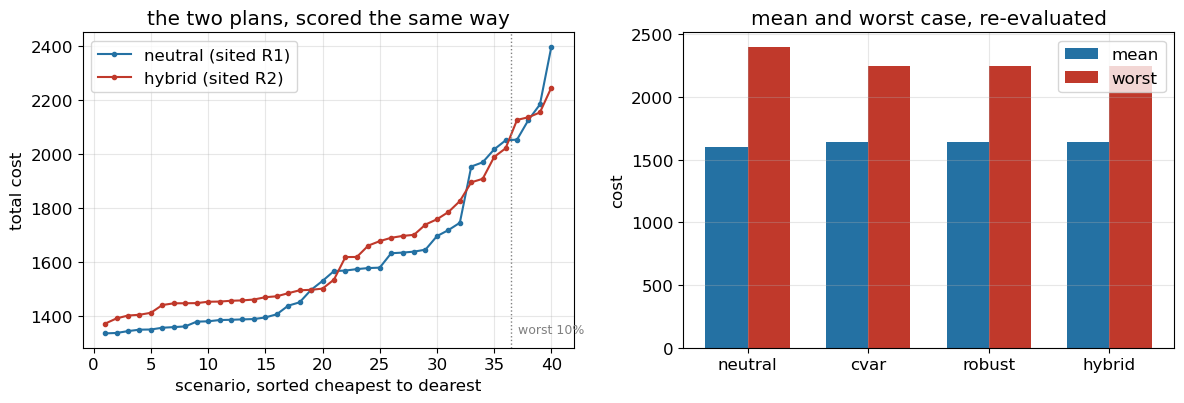

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for m, col in (("neutral", "#2471a3"), ("hybrid", "#c0392b")):
    ax[0].plot(range(1, NK + 1), ev[m]["dist"], "o-", ms=3, color=col,
               label=f"{m} (sited {table.loc[table.objective == m, 'sited'].iloc[0]})")
ax[0].set_xlabel("scenario, sorted cheapest to dearest")
ax[0].set_ylabel("total cost")
ax[0].set_title("the two plans, scored the same way")
ax[0].legend()

cut = NK - max(1, int(round(ALPHA * NK)))
ax[0].axvline(cut + 0.5, color="grey", ls=":", lw=1)
ax[0].text(cut + 0.7, min(ev["neutral"]["dist"]), f" worst {ALPHA:.0%}",
           fontsize=9, color="grey")

w = 0.35
xs = range(len(table))
ax[1].bar([x - w / 2 for x in xs], table["mean"], w, color="#2471a3", label="mean")
ax[1].bar([x + w / 2 for x in xs], table["worst"], w, color="#c0392b", label="worst")
ax[1].set_xticks(list(xs))
ax[1].set_xticklabels(table["objective"])
ax[1].set_ylabel("cost")
ax[1].set_title("mean and worst case, re-evaluated")
ax[1].legend()
fig.tight_layout()
plt.show()

## 8. The dials, and why the frontier is a staircase

$\lambda$ trades the mean against CVaR; $\alpha$ says how much of the tail
counts. The usual picture is a smooth efficient frontier.

> **Predict before you run.** Sweeping $\lambda$ from 0 to 1, how many distinct
> plans do you expect to see?

In [13]:
rows = []
for lam in (0.0, 0.005, 0.01, 0.05, 0.15, 0.3, 0.4, 0.7, 1.0):
    r = risk_model("hybrid", lam=lam)
    e = evaluate(r["plan"])
    rows.append(dict(lam=lam, sited=("R1" if r["plan"]["MINE", "R1"] > 1e-6 else "R2"),
                     mean=round(e["mean"], 1), cvar=round(e["cvar"], 1),
                     worst=round(e["worst"], 1)))
lam_sweep = pd.DataFrame(rows)
n_plans = lam_sweep[["mean", "cvar", "worst"]].drop_duplicates().shape[0]
print(f"{len(lam_sweep)} values of lambda produced {n_plans} distinct outcomes")
assert n_plans == 2, (
    f"the lambda sweep produced {n_plans} distinct plans; section 8's claim that "
    f"the frontier is a staircase with two steps needs rewriting")
lam_sweep

9 values of lambda produced 2 distinct outcomes


,lam,sited,mean,cvar,worst
0,0.000,R2,1642.2,2164.8,2245.5
1,0.005,R2,1642.2,2164.8,2245.5
2,0.010,R2,1642.2,2164.8,2245.5
3,0.050,R2,1642.2,2164.8,2245.5
4,0.150,R2,1642.2,2164.8,2245.5
5,0.300,R2,1642.2,2164.8,2245.5
6,0.400,R1,1602.1,2189.3,2397.0
7,0.700,R1,1602.1,2189.3,2397.0
8,1.000,R1,1602.1,2189.3,2397.0


Now $\alpha$, holding the objective at pure CVaR. Small $\alpha$ means a narrow
tail and a more cautious plan; $\alpha = 1$ means the whole distribution is the
tail, at which point CVaR *is* the mean — which is the free correctness check at
the end of the cell.

In [14]:
rows = []
for a in (0.05, 0.10, 0.20, 0.35, 0.50, 1.0):
    r = risk_model("cvar", alpha=a)
    e = evaluate(r["plan"])
    ncrit = max(1, int(round(a * NK)))
    rows.append(dict(alpha=a, sited=("R1" if r["plan"]["MINE", "R1"] > 1e-6 else "R2"),
                     tail_scenarios=ncrit, mean=round(e["mean"], 1),
                     cvar_at_alpha=round(sum(e["dist"][-ncrit:]) / ncrit, 1),
                     worst=round(e["worst"], 1)))
alpha_sweep = pd.DataFrame(rows)

last = alpha_sweep.iloc[-1]
assert abs(last.cvar_at_alpha - last["mean"]) < 0.05, (
    "at alpha = 1 CVaR must equal the mean, since the whole distribution is "
    "the tail; it does not, so the CVaR computation is wrong")
print(f"at alpha = 1.0, CVaR {last.cvar_at_alpha} equals the mean "
      f"{last['mean']} - the whole distribution is the tail")
alpha_sweep

at alpha = 1.0, CVaR 1602.1 equals the mean 1602.1 - the whole distribution is the tail


,alpha,sited,tail_scenarios,mean,cvar_at_alpha,worst
0,0.05,R2,2,1642.2,2199.3,2245.5
1,0.10,R2,4,1642.2,2164.8,2245.5
2,0.20,R2,8,1642.2,2058.5,2245.5
3,0.35,R1,14,1602.1,1915.2,2397.0
4,0.50,R1,20,1602.1,1815.1,2397.0
5,1.00,R1,40,1602.1,1602.1,2397.0


**Both sweeps are staircases with exactly two steps, and the assertion above
requires it.** $\lambda \le 0.3$ sites in R2 and $\lambda \ge 0.4$ sites in R1;
$\alpha \le 0.20$ sites in R2 and $\alpha \ge 0.35$ in R1. Nothing in between,
because there is nothing in between to choose — the plan space here contains two
sensible points and the dial only decides which side of the threshold you are on.

That is worth knowing before drawing a smooth frontier through five markers. A
risk-return curve with a continuum of plans on it is a property of problems whose
first stage is continuous; with binaries you generally get a staircase, and the
interesting question is *where the step is*, not what the curve looks like.

The $\alpha = 1$ row is the free check: CVaR over the whole distribution is the
mean, and the cell asserts it. If the Rockafellar–Uryasev block were wrong, this
is the row that would show it.

## 9. The agreement assertion

`src/lithium/twostage.py` holds the same models. What this compares needs care,
because section 6 established that some of these quantities are **not
well-defined**:

- The **objective value** of each model is well defined and is compared.
- The **capacity plan** is compared.
- The **re-evaluated** distribution is compared, because it is the thing that is
  reproducible.
- The **reported mean** is *not* compared for `cvar` and `robust`, because it is
  not a property of the model — asserting on it would be asserting on which of
  several tied recourse solutions the solver happened to return, and the
  assertion would fail on a different Gurobi version for no real reason.

Refusing to assert on a number you have shown to be arbitrary is part of the
exercise, not a gap in it.

In [15]:
from lithium import TwoStageInstance, build_twostage_structure
from lithium import twostage as T2

nb_inst = TwoStageInstance(
    stages=STAGES, regions=REGIONS, fix=FIX, unit=UNIT, opc=OPC, eta=ETA,
    demand_base=DEMAND_BASE, region_cost=REGION_COST)
nb_st = build_twostage_structure(nb_inst, cmin=CMIN, cmax=CMAX, pen=PEN,
                                 tau_own=TAU_OWN, tau_cross=TAU_CROSS)
pkg_scen = T2.shock_scenarios(nb_st, n=NK, seed=SEED, lo=LO, span=SPAN,
                              hit_prob=HIT_PROB, hit_size=HIT_SIZE,
                              steady_jitter=STEADY_JITTER, disrupted=DISRUPTED)

wd = max(abs(pkg_scen[k][2][r] - SCEN[k][2][r]) for k in range(NK) for r in REGIONS)
wm = max(abs(pkg_scen[k][3][r] - SCEN[k][3][r]) for k in range(NK) for r in REGIONS)
print(f"{'scenario demands':28s} max abs diff {wd:.2e}")
print(f"{'scenario shock multipliers':28s} max abs diff {wm:.2e}")
assert wd < 1e-12 and wm < 1e-12, "the notebook and the package disagree on the tree"

scenario demands             max abs diff 0.00e+00
scenario shock multipliers   max abs diff 0.00e+00


With the tree reconstructed exactly, the four models can be compared. The last
column is the one that matters most: the re-evaluated mean, which is the quantity
section 6 showed to be the only reproducible one.

In [16]:
print(f"{'mode':9s} {'objective (nb)':>15s} {'objective (pkg)':>16s} {'rel':>9s}"
      f"   plan   re-evaluated mean")
for mode in ("neutral", "cvar", "robust", "hybrid"):
    a = res[mode]
    b = T2.risk_model(nb_st, pkg_scen, mode, alpha=ALPHA, lam=LAM, mipgap=MIPGAP)
    rel = abs(a["obj"] - b["model"].ObjVal) / abs(b["model"].ObjVal)
    wp = max(abs(a["plan"][n] - b["plan"][n]) for n in NODES)
    eb = T2.evaluate_capacity(nb_st, pkg_scen, b["plan"])
    rm = abs(ev[mode]["mean"] - eb["mean"]) / abs(eb["mean"])
    print(f"{mode:9s} {a['obj']:15.6f} {b['model'].ObjVal:16.6f} {rel:9.1e}"
          f"   {wp:.0e}   {rm:.1e}")
    assert rel < 1e-9, f"{mode}: objectives disagree by {rel:.2e}"
    assert wp < 1e-6, f"{mode}: capacity plans differ by {wp:.2e}"
    assert rm < 1e-9, f"{mode}: re-evaluated means disagree by {rm:.2e}"

print("\nnotebook and package agree on the tree, all four objectives, all four")
print("plans, and every re-evaluated distribution - and deliberately do not")
print("compare the reported means, which section 6 showed are not well defined")

mode       objective (nb)  objective (pkg)       rel   plan   re-evaluated mean
neutral       1602.075817      1602.075817   0.0e+00   0e+00   0.0e+00


cvar          2164.792608      2164.792608   0.0e+00   0e+00   0.0e+00


robust        2245.473308      2245.473308   0.0e+00   0e+00   0.0e+00
hybrid        2159.566591      2159.566591   0.0e+00   0e+00   0.0e+00

notebook and package agree on the tree, all four objectives, all four
plans, and every re-evaluated distribution - and deliberately do not
compare the reported means, which section 6 showed are not well defined


## 10. Summary

| Question | Answer |
|---|---|
| How many distinct plans do the four objectives choose? | **Two.** Only the risk-neutral one sites in R1 |
| Is the robust plan expensive on average? | **No** — it is the CVaR plan. True mean 1642.2, not the 2245.5 it reports |
| Does risk aversion build more capacity? | **No.** Same capex 1144.4, same 196.3 units, moved to R2 |
| What does the hedge cost? | +2.50% on the mean, for −6.32% on the worst case |
| Is the risk-return frontier smooth? | **No** — two steps, λ flipping between 0.3 and 0.4 |
| Does CVaR at α = 1 equal the mean? | Yes, and that is the check that the CVaR block is right |

### Formulation lessons

- **CVaR linearises.** One free variable and one constraint per scenario, and
  the sort disappears. The technique is easy; reading the output is not.
- **A solution vector is not a set of results.** Minimax pins only the worst
  scenario; pure CVaR only the tail. Everything else in the solution is whatever
  the solver happened to return, and averaging it produces a confident number
  about nothing.
- **Score every plan by asking it the same question.** Fix the first stage,
  re-optimise the recourse, read the distribution. This is the same discipline
  Part 2 needed for WS/RP/EEV, and it changed a headline by 37% here.
- **Do not assert on a degenerate quantity.** The reported mean is arbitrary, so
  the agreement assertion deliberately leaves it alone rather than pinning a
  number that has no right to be stable.
- **A binary first stage gives a staircase, not a frontier.** Look for where the
  step is.

### Things to try

- `REGION_COST["R1"] = 1.00` in section 2 — remove the cost advantage and watch
  the risk-neutral plan move to R2 as well, collapsing the whole trade-off
- `HIT_SIZE = 0.5` — a mild disruption, and see whether any objective still
  bothers to relocate
- `HIT_PROB = 0.5` — frequent disruption stops being a tail risk and starts
  being the mean, which is a different problem
- `SEED = 8` — the same generator, a different draw; does the step move?
- Compare `risk_model("robust")["reported_mean"]` against
  `evaluate(res["robust"]["plan"])["mean"]` on your machine, and see which of
  section 6's five values you get

### Where this goes next

**Part 3** returns to the network core and to deterministic modelling, with the
production detail these two-stage notebooks deliberately left out.